In [2]:
import torch

if torch.cuda.is_available():
    print("CUDA is available!")
    device = torch.device('cuda')
else:
    print("CUDA is not available. Using CPU.")
    device = torch.device('cpu')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import os
import json
import pickle

import tkinter as tk
import pandas as pd
import cv2
import torch
import torchvision

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler

CUDA is not available. Using CPU.


import torch: Импортирует библиотеку PyTorch для работы с нейронными сетями.
Определение устройства (device):
Проверяет, доступна ли CUDA (GPU) с помощью torch.cuda.is_available().
Если CUDA доступна, устанавливает device на 'cuda', чтобы использовать GPU.
Иначе, устанавливает device на 'cpu', чтобы использовать CPU.
Импорт библиотек: Импортирует необходимые библиотеки для:
Численных вычислений (numpy).
Визуализации (matplotlib.pyplot).
Работы с файловой системой (os).
Работы с данными в формате JSON (json) и pickle (pickle).
Создания графического интерфейса (tkinter).
Работы с табличными данными (pandas).
Обработки изображений (cv2).
Дополнительных модулей PyTorch (torch.nn, torch.nn.functional, torch.optim, torch.optim.lr_scheduler).

In [3]:
#pip install opencv-python-headless

In [3]:
#pip install torch torchvision torchaudio


In [4]:
#pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu/torchvision-0.17.1%2Bcpu-cp310-cp310-linux_x86_64.whl

# 0.Dataset/Corresponding labels/Classifier

In [3]:
"""
0.0 Reading mov of static image 
"""
###
if_rotate=False # Rotate 90 if needed
###
cap = cv2.VideoCapture("workspace_physical/static.mov")
frame_list=[]
while(cap.isOpened()):
    ret, frame = cap.read()
    
    if ret == True:
        if if_rotate:
            frame=cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE)
        frame_list.append(frame)
    else:
        break
cap.release()

В итоге, этот код читает видеофайл “workspace_physical/static.mov”, извлекает все кадры, возможно, поворачивает их, и сохраняет их в список frame_list.

True

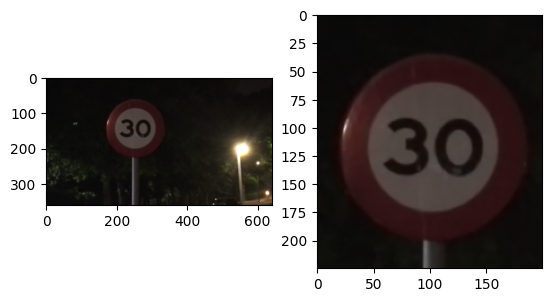

In [4]:
"""
0.1 Select bound for more quality result.
and store victim image 
"""
###
x_bound=(25,250)
y_bound=(150,350)
###

static_img=np.mean(frame_list,axis=0) # mean of multi frames to reduce noise
static_img=np.round(static_img)/255
plt.subplot(1,2,1)
plt.imshow(static_img[:,:,::-1])
plt.subplot(1,2,2)
plt.imshow(static_img[x_bound[0]:x_bound[1],y_bound[0]:y_bound[1]][:,:,::-1])

test_img=static_img[x_bound[0]:x_bound[1],y_bound[0]:y_bound[1]]
cv2.imwrite('workspace_physical/source.png', (test_img*255).astype("uint8"))

В итоге, этот код усредняет кадры из видео, обрезает область интереса, отображает исходное и обрезанное изображения, и сохраняет обрезанное изображение в файл “workspace_physical/source.png”.

In [5]:
"""
0.2 Reading dictionary of label
"""
###
DATASET="RTSD"
###
with open("params.json", "r") as config:
    params = json.load(config)
    CLASS_N = params[DATASET]["class_n"]
    LABELS = params[DATASET]["labels"]
    CLASSIFIER_INPUT_SHAPE=params[DATASET]["classifier_input_shape"]
    device = params["device"]

In [6]:
class GTSRB_MODEL(nn.Module):
    def __init__(self, output_dim):
        """
        Initializing the model
        """

        super(GTSRB_MODEL,self).__init__()
        self.input_dim = 3*50*50
        self.output_dim = output_dim

        self.metrics = {}

        self.flatten = nn.Flatten()

        self.dropout2 = nn.Dropout(0.2)
        self.dropout3 = nn.Dropout(0.3)

        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2)

        # building layers
        self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        self.batchnorm1 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1)
        self.conv4 = nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1)
        self.batchnorm2 = nn.BatchNorm2d(256)

        self.conv5 = nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3)
        self.conv6 = nn.Conv2d(in_channels=512,out_channels=1024,kernel_size=3)
        self.batchnorm3 = nn.BatchNorm2d(1024)


        self.l1 = nn.Linear(1024*4*4,512)
        self.l2 = nn.Linear(512,128)
        self.batchnorm4 = nn.LayerNorm(128)
        self.l3 = nn.Linear(128,output_dim)


    def forward(self, input):
        """
        Forward propagation...
        """

        conv = self.conv1(input)
        conv = self.conv2(conv)
        batchnorm = self.relu(self.batchnorm1(conv))
        maxpool = self.maxpool(batchnorm)

        conv = self.conv3(maxpool)
        conv = self.conv4(conv)
        batchnorm = self.relu(self.batchnorm2(conv))
        maxpool = self.maxpool(batchnorm)

        conv = self.conv5(maxpool)
        conv = self.conv6(conv)
        batchnorm = self.relu(self.batchnorm3(conv))
        maxpool = self.maxpool(batchnorm)

        flatten = self.flatten(maxpool)

        dense_l1 = self.l1(flatten)
        dropout = self.dropout3(dense_l1)
        dense_l2 = self.l2(dropout)
        batchnorm = self.batchnorm4(dense_l2)
        dropout = self.dropout2(batchnorm)
        output = self.l3(dropout)


        return output

In [7]:
"""
0.3 Reading model of corresponding classifer 
"""
#from model import GTSRB_MODEL
###
CLASSIFIER_MODEL=GTSRB_MODEL
CLASSIFIER_PATH="model/cnn_rtsd_final.pt"
###
print("CUDA Available: ", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)

classifier = CLASSIFIER_MODEL(CLASS_N).to(device)
if torch.cuda.is_available():
    classifier.load_state_dict(torch.load(CLASSIFIER_PATH))
else:
    classifier.load_state_dict(torch.load(CLASSIFIER_PATH, map_location=torch.device('cpu')))
print("Classifier Path =", CLASSIFIER_PATH)


CUDA Available:  False
Device: cpu
Classifier Path = model/cnn_rtsd_final.pt


КУСОК ИЗ ДРУГОГО КОДА

In [8]:
import torch
import torchvision.transforms as transforms
from PIL import Image  # Для загрузки изображений
import numpy as np
import torch.nn.functional as F # for loss function


# 1. Загрузка модели
def load_model(model_path, device='cpu'):
    """Загружает PyTorch модель с указанного пути."""
    # 1. Создаем экземпляр модели
    INPUT_DIM = 3 * 50 * 50  # Замените на правильное значение
    OUTPUT_DIM = 106  # Замените на правильное значение
    model = GTSRB_MODEL(OUTPUT_DIM).to(device)

    # 2. Загружаем state_dict в модель
    model.load_state_dict(torch.load(model_path, map_location=torch.device(device)))

    # 3. Переводим модель в режим eval
    model.eval()
    return model


# 2. Предобработка изображений (должна соответствовать предобработке, использованной при обучении модели!)
def preprocess_image(image_path, img_size=(50, 50)): # Замените (32,32) на размер, используемый при обучении
    """Предобрабатывает изображение."""
    try:
        img = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
        return None
    except Exception as e:
        print(f"Error opening image: {e}")
        return None

    transform = transforms.Compose([
        transforms.Resize(img_size), # Resize if needed
        transforms.ToTensor()
    ])

    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    return img_tensor

In [9]:
import torch
import torch.nn.functional as F

def check_photo(model_path, image_path, device='cpu'):
    """
    Пропускает изображение через модель и возвращает предсказанный класс и уверенность.

    Args:
        model_path (str): Путь к файлу модели.
        image_path (str): Путь к файлу изображения.
        device (str): Устройство для выполнения вычислений ('cpu' или 'cuda').

    Returns:
        tuple: (predicted_class, confidence_score), или (None, None) в случае ошибки.
    """
    # 1. Загрузка модели
    model = load_model(model_path, device)

    # 2. Предобработка изображения
    image_tensor = preprocess_image(image_path)
    if image_tensor is None:
        return None, None

    # 3. Пропускаем изображение через модель (без атаки)
    with torch.no_grad():  # Отключаем вычисление градиентов
        output = model(image_tensor.to(device))
        _, predicted_class = torch.max(output.data, 1)
        confidence = F.softmax(output, dim=1)
        confidence_score = confidence.max().item()

    # Возвращаем предсказанный класс и уверенность модели
    return predicted_class.item(), confidence_score



Predicted class: 31
Confidence: 0.9998


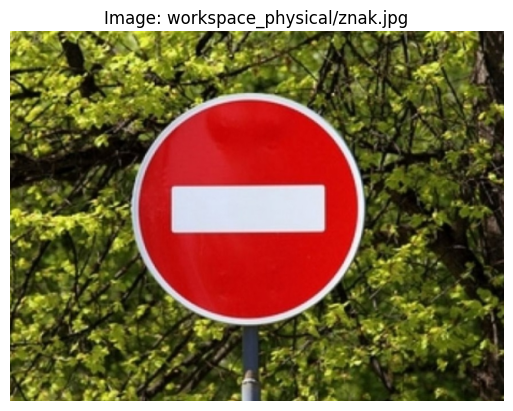

In [10]:
# Пример использования
model_path = 'model/cnn_rtsd_final.pt'
image_path = "workspace_physical/znak.jpg"  # Замени на путь к файлу изображения

predicted_class, confidence = check_photo(model_path, image_path)

if predicted_class is not None:
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")
else:
    print("Error processing image.")

try:
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(f"Image: {image_path}")
    plt.axis('off') # Turn off axes numbers
    plt.show()
except FileNotFoundError:
    print(f"Error: Image not found at {image_path}")
except Exception as e:
    print(f"Error displaying image: {e}")

(128, 128)


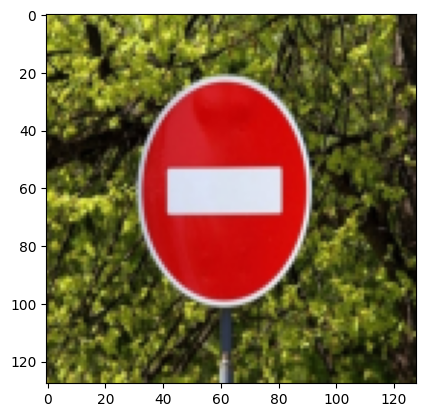

In [11]:
"""
0.4 Read in victim image and corresponding classification 
"""
###
RESIZED_SHAPE=(128,128) # influence the resolution of light generator and ZOO optimizer
###
test_img_ = cv2.imread("workspace_physical/znak.jpg")
test_img = cv2.resize(test_img_, RESIZED_SHAPE, interpolation=cv2.INTER_AREA)
test_img=test_img.astype(np.float32)/255
###
print(test_img[:, :, 0].shape)
plt.imshow(test_img[:, :, ::-1])

Модель успешно загружена!
Predict: 31 Confidence: 99.98%
Top 1 (99.98%) = 31 ...
Top 2 (0.01%) = 0 ...
Top 3 (0.01%) = 24 ...
Top 4 (0.00%) = 54 ...
Top 5 (0.00%) = 12 ...
Top 6 (0.00%) = 47 ...
Top 7 (0.00%) = 50 ...
Top 8 (0.00%) = 103 ...


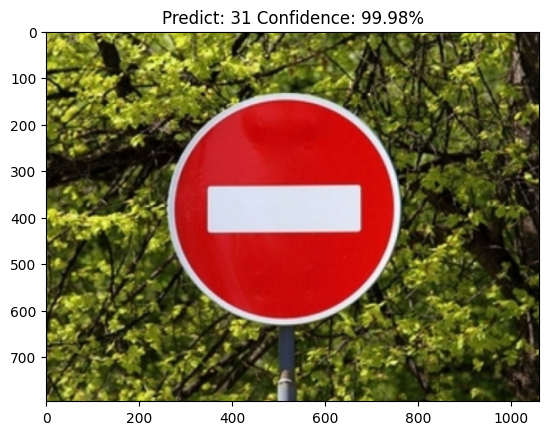

In [12]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Отключаем видимость GPU для PyTorch
import torch
import torchvision.transforms as transforms
from PIL import Image  # Используем PIL для единообразия
import matplotlib.pyplot as plt
import numpy as np

#  Определяем device (CPU или GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# (Предполагаем, что classifier, CLASSIFIER_INPUT_SHAPE, LABELS определены)

# Загрузка модели (УБЕДИТЕСЬ, что модель загружается на CPU, если CUDA недоступна)
try:
    if torch.cuda.is_available():
        classifier.load_state_dict(torch.load('model/cnn_rtsd_final.pt'))
    else:
        classifier.load_state_dict(torch.load('model/cnn_rtsd_final.pt', map_location=torch.device('cpu')))
    print("Модель успешно загружена!")
except FileNotFoundError:
    print("Файл cnn_rtsd_final.pt не найден. Проверьте путь к файлу.")
except RuntimeError as e:
    print(f"Ошибка при загрузке state_dict: {e}")
    print("Убедитесь, что архитектура модели соответствует архитектуре, для которой были сохранены веса.")

# Переносим модель на выбранное устройство
classifier.to(device)
# Переводим модель в режим eval
classifier.eval()

# Определяем преобразования (ИСПОЛЬЗУЕМ ТО ЖЕ, ЧТО И В РАБОЧЕМ КОДЕ!)
transform = transforms.Compose([
    transforms.Resize(CLASSIFIER_INPUT_SHAPE),  #  Размер
    transforms.ToTensor()  # Преобразуем в тензор
    #transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Ваша нормализация (ЕСЛИ ИСПОЛЬЗОВАЛАСЬ)
])

try:
    # Загружаем изображение с использованием PIL (КАК В РАБОЧЕМ КОДЕ!)
    image_path = "workspace_physical/znak.jpg" # Замените на свой путь
    img = Image.open(image_path).convert('RGB')

    # Преобразуем изображение
    tensor_img = transform(img).to(device)
    tensor_img = tensor_img.unsqueeze(0) # Добавляем batch dimension

    # Отключаем вычисление градиентов
    with torch.no_grad():
        # Получаем предсказания модели
        predict = torch.softmax(classifier(tensor_img).squeeze(), dim=-1)

        # Получаем индекс класса с наибольшей вероятностью и уверенность
        index = torch.argmax(predict).item()
        confidence = predict[index].item()

        # Записываем GROUND TRUTH (исправлено)
        GROUND_TRUTH = torch.tensor([index]).to(device)  # Переносим на то же устройство

        # Выводим результаты
        print(f"Predict: {LABELS[index]} Confidence: {confidence * 100:.2f}%")

        # Отображаем изображение (исправлено)
        plt.imshow(img)  #  Отображаем PIL изображение
        plt.title(f"Predict: {LABELS[index]} Confidence: {confidence * 100:.2f}%")

        # Выводим топ-8 предсказаний
        probs, indices = torch.topk(predict, k=8)
        probs = probs.tolist()
        indices = indices.tolist()

        for i, (indice, p) in enumerate(zip(indices, probs), 1):
            label = LABELS[indice]
            print(f"Top {i} ({p * 100:.2f}%) = {label[:25]} ...")

        # Отображаем график
        plt.show()

except Exception as e:
    print(f"Произошла ошибка: {e}")

# 1.Mask Drawer

In [13]:
"""
1.1 reading target video with lights on victim object
"""
###
SHAPE_RESIZED=(128,128) # influence the resolution of generator and ZOO optimizer
PATH_source="workspace_physical/source.png"
###
source_img = cv2.imread(PATH_source)
source_img = cv2.resize(source_img, SHAPE_RESIZED, interpolation=cv2.INTER_CUBIC)
test_img = source_img.astype(np.float32)/255.0

In [ ]:
"""
1.2 record all training target: target_0.mov, target_1.mov ....
"""
import re
target_nums=0
for filename in os.listdir("workspace_physical"):
    pattern_num=re.compile("target_")
    find = re.search(pattern_num, filename)
    if find !=None:
        target_nums+=1
    
print(target_nums)

2


In [15]:
from mask import mask_extract,mask_save,mask_demo
mask_extract(source_img, target_nums, if_rotate,x_bound, y_bound)

: 

In [16]:
"""
1.5 If you satisfy the mask result then concate all existing sub-data you want to train together
"""
mask_save()

Total target(Train) shape= (1158, 128, 128, 3)
Total target( Val ) shape= (127, 128, 128, 3)


# 2. Object-Dependent Light Generator

In [17]:
"""
2.1 Initialize Light Generator 
"""
from model import Generator
###
GENERATOR_MODEL=Generator
GENERATOR_INIT="model/pre_light_generator.pt" # From pre-train stage
###
print("CUDA Available: ", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)

light_generator = GENERATOR_MODEL(gen_input_nc=4, image_nc=3).to(device) # 4 = static+mask
if (GENERATOR_INIT):
     light_generator.load_state_dict(torch.load(GENERATOR_INIT, map_location=torch.device('cpu'))["model_state_dict"])
    

CUDA Available:  False
Device: cpu


In [18]:
"""
2.2 Dataset for training Light Generator 
"""
from light_generator import GAN_dataset
###
PATH_traindata="dataset/physical/train_data.npy"
PATH_traintarget="dataset/physical/train_target.npy"
PATH_valdata="dataset/physical/val_data.npy"
PATH_valtarget="dataset/physical/val_target.npy"
batch_size=16
###
load_augmentation=torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
               #torchvision.transforms.RandomRotation(degrees=(-30,30))
                                                 ])   
load_transform = torchvision.transforms.ToTensor()

train_dataset = GAN_dataset(PATH_traindata,PATH_traintarget,load_augmentation)
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataset =  GAN_dataset(PATH_valdata,PATH_valtarget,load_transform)
val_loader = torch.utils.data.DataLoader(val_dataset,batch_size=batch_size,shuffle=True)

In [19]:
"""
2.3 Learning Module of Light Generator
"""
G_criterion = nn.MSELoss()

lr_G = 0.0002
beta1 = 0.5 # Beta1 hyperparam for Adam optimizers

optimizerG = optim.Adam(light_generator.parameters(), lr = lr_G, betas=(beta1, 0.999))
schedulerG = torch.optim.lr_scheduler.StepLR(optimizerG, 100, gamma=0.5)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0047940984..1.0752509].


epoch = 0, G_loss_MSE = 0.00104


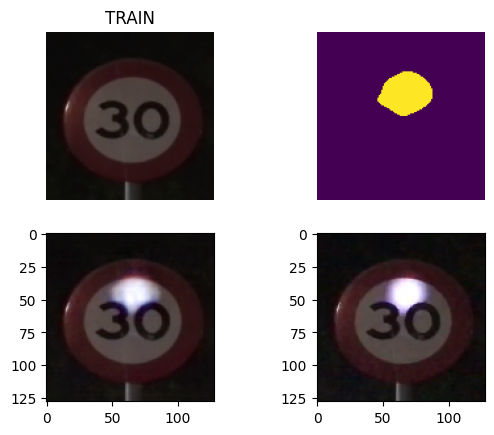

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.020092705..1.084361].


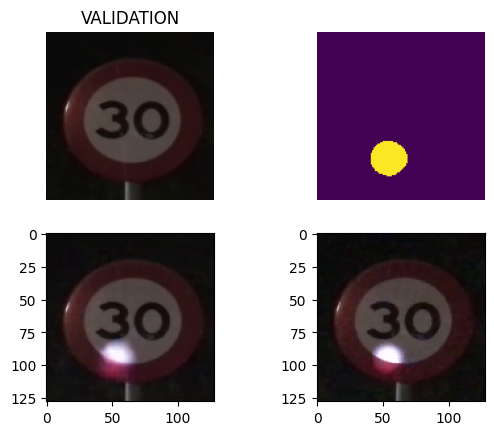

#Validation, G_loss = 0.00119#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.026011761..1.1117313].


epoch = 5, G_loss_MSE = 0.00052


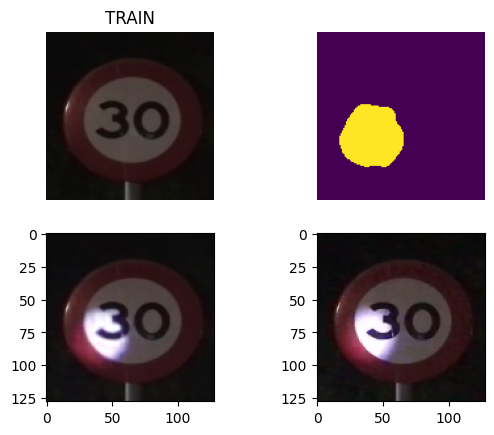

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014676992..1.114645].


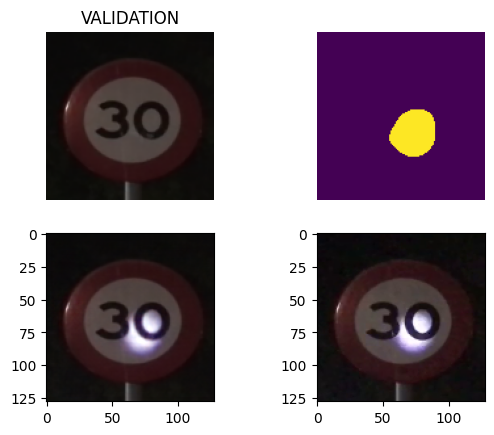

#Validation, G_loss = 0.00050#
epoch = 10, G_loss_MSE = 0.00041


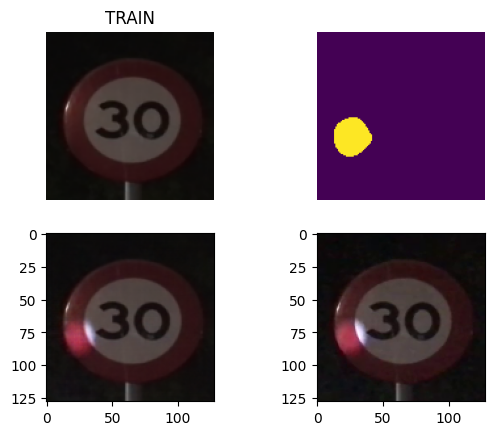

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.013268767..0.9285532].


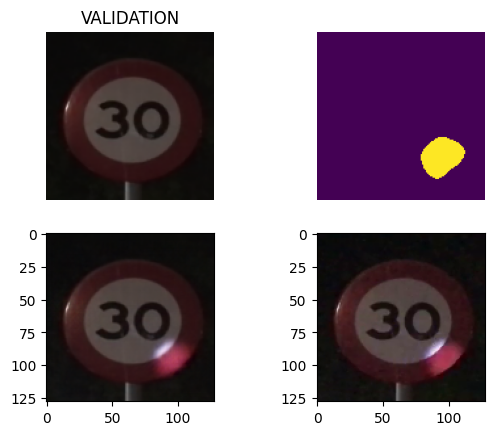

#Validation, G_loss = 0.00043#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.026585523..1.1169072].


epoch = 15, G_loss_MSE = 0.00038


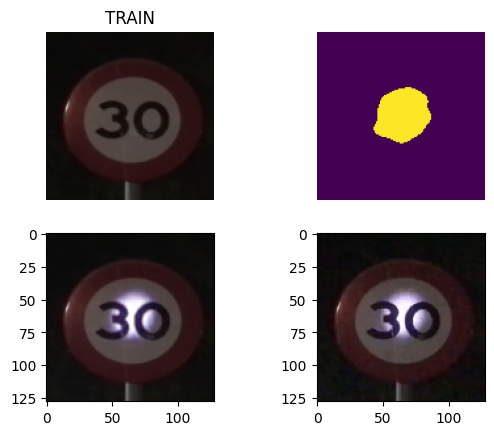

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.4098124e-06..1.1021096].


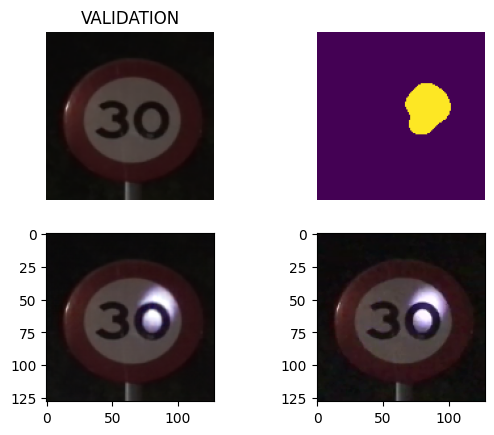

#Validation, G_loss = 0.00040#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.019961786..1.0916986].


epoch = 20, G_loss_MSE = 0.00039


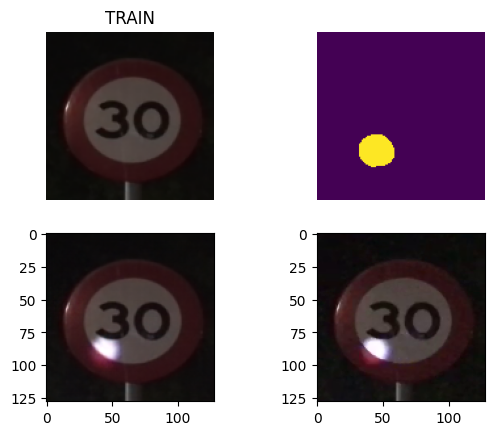

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021829478..1.07999].


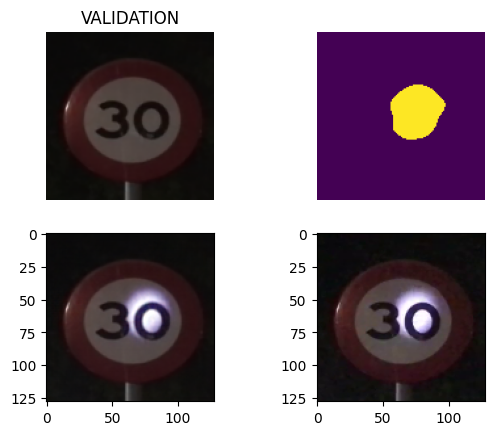

#Validation, G_loss = 0.00037#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0046078265..1.0813562].


epoch = 25, G_loss_MSE = 0.00038


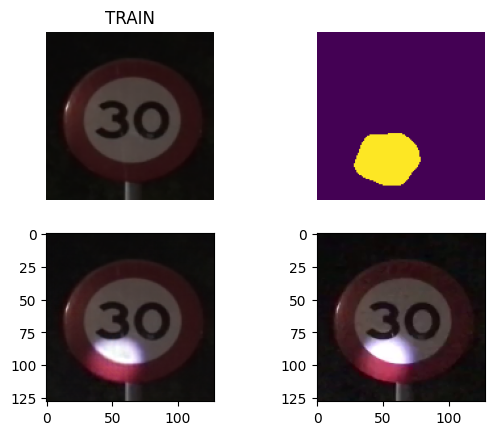

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021837085..1.139713].


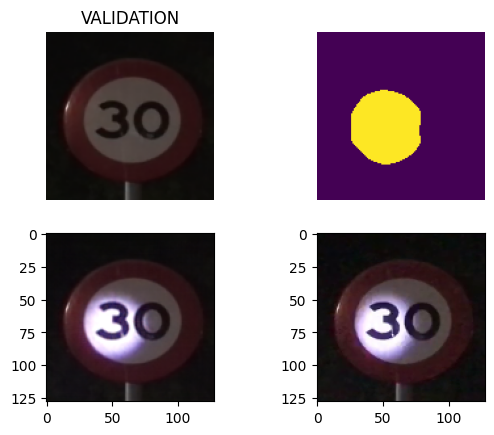

#Validation, G_loss = 0.00046#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0106233..1.1132921].


epoch = 30, G_loss_MSE = 0.00029


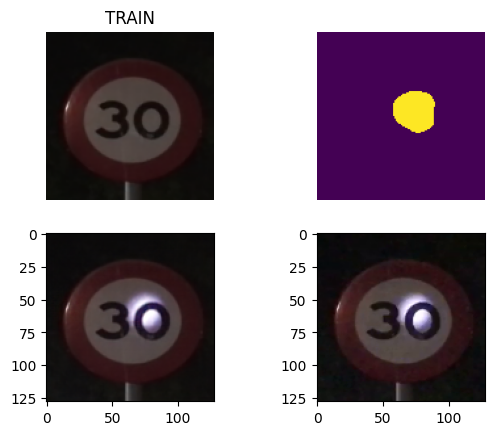

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0036717616..1.026869].


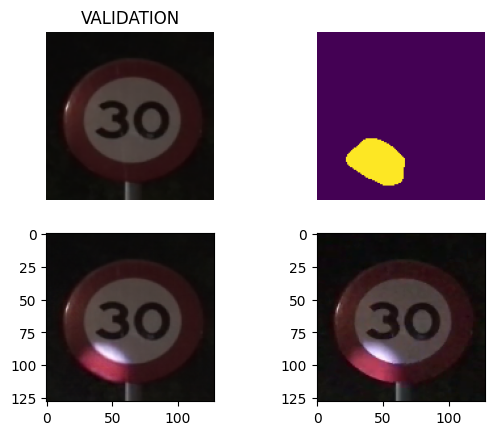

#Validation, G_loss = 0.00037#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0075891074..1.0464035].


epoch = 35, G_loss_MSE = 0.00030


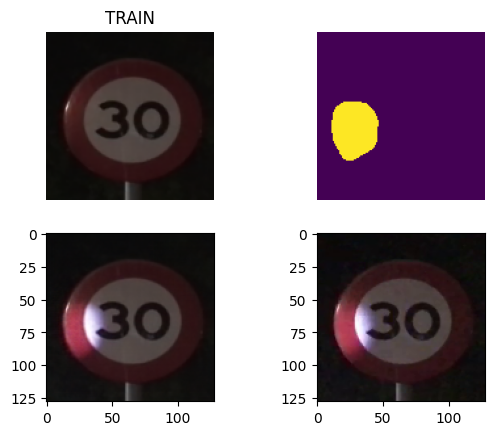

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.024414556..1.0701967].


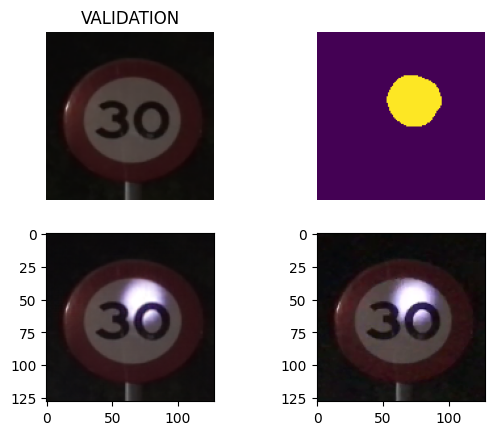

#Validation, G_loss = 0.00032#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.416921e-05..1.0864637].


epoch = 40, G_loss_MSE = 0.00026


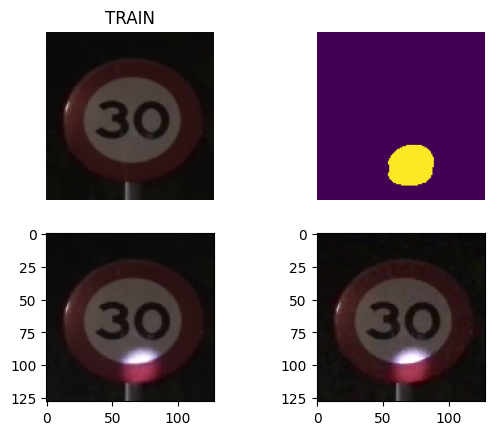

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0035173912..1.0611107].


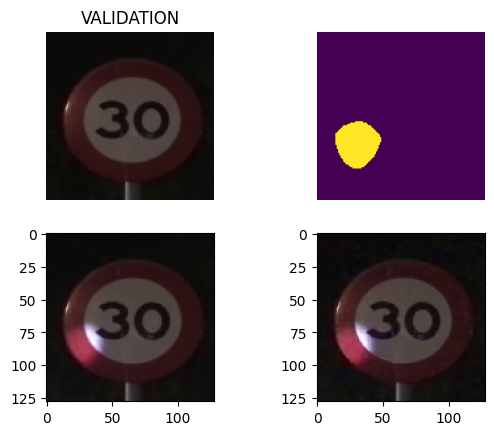

#Validation, G_loss = 0.00032#


In [19]:
from light_generator import train

train(light_generator,optimizerG,schedulerG,G_criterion,train_loader,val_loader,num_epochs=41,Freq_print=5,Freq_plot=5)

In [77]:
"""
ПОПЫТКА ДВА 0.4 Read in victim image and corresponding classification 
"""
"""
1.1 reading target video with lights on victim object
"""
###
SHAPE_RESIZED=(128,128) # influence the resolution of generator and ZOO optimizer
PATH_source="workspace_physical/znak.jpg"
###
source_img = cv2.imread(PATH_source)
source_img = cv2.resize(source_img, SHAPE_RESIZED, interpolation=cv2.INTER_CUBIC)
test_img = source_img.astype(np.float32)/255.0

[53, 65, 14]


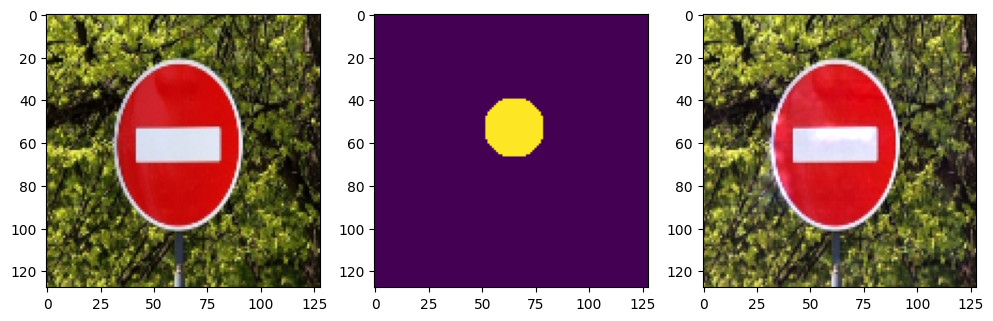

In [78]:
"""
2.5 Demo Light Generator with Random mask
"""
from light_generator import simulate_light_circle,simulate_light_elipse,simulate_light_polygon
###
min_list=[40,40,10] # (x,y,r)
max_list=[80,80,25]
mask_pos=[np.random.randint(min_list[i], max_list[i]) for i in range(len(min_list))]
print(mask_pos)
###



light_generator=GENERATOR_MODEL(gen_input_nc=4, image_nc=3).to(device)
light_generator.load_state_dict(torch.load("model/light_generator.pt", map_location=torch.device('cpu'))["model_state_dict"])
sim,mask=simulate_light_circle(light_generator, source_img, mask_pos)

plt.figure(figsize=(12,12))
plt.subplot(1,3,1)
plt.imshow(source_img[:,:,::-1])

plt.subplot(1,3,2)
plt.imshow(mask)

plt.subplot(1,3,3)
plt.imshow(sim[:,:,::-1])

In [79]:
print(source_img)

[[[ 65 194 187]
  [ 39 168 161]
  [ 74 185 177]
  ...
  [ 32  41  50]
  [ 11  18  27]
  [ 24  32  36]]

 [[ 79 192 188]
  [ 44 161 156]
  [ 41 144 139]
  ...
  [  8  19  23]
  [ 16  23  32]
  [ 41  49  56]]

 [[120 213 212]
  [ 28 122 121]
  [ 21 127 124]
  ...
  [ 11  23  25]
  [ 18  27  36]
  [ 35  46  54]]

 ...

 [[  9  40  42]
  [ 23  63  62]
  [ 23  70  61]
  ...
  [ 19  37  44]
  [ 15  28  36]
  [  0  11  13]]

 [[118 179 180]
  [ 17  74  73]
  [ 12  73  63]
  ...
  [ 19  38  45]
  [ 27  43  49]
  [ 31  62  63]]

 [[ 45 132 140]
  [ 23 101  98]
  [ 21 102  88]
  ...
  [ 16  34  41]
  [  8  21  27]
  [  6  30  32]]]


# 3.ZOO attack optimizer

In [1]:
from optimize import ZeroOrderOptimizer

###
test_img
criteria = nn.CrossEntropyLoss()
label_attack = GROUND_TRUTH[0]

#############################################################
pos_min_list=[0.3*RESIZED_SHAPE[0], 0.3*RESIZED_SHAPE[1],30] # specify lower bound of each dimension (x1,y1,x2,y2,x3,y3)
pos_max_list=[0.7*RESIZED_SHAPE[0], 0.7*RESIZED_SHAPE[1],10] # specify upper bound of each dimension
###
ZOO_optimizer = ZeroOrderOptimizer(
    source_img, # victim image
    iter=6, # optimize iter of each start point
    label=GROUND_TRUTH.squeeze(),
    attack_model=classifier,
    light_generator=light_generator,
    criteria=criteria, # score criteria
    point_num=5, # number of start point
    draw_light=simulate_light_circle, # draw mask from pos-space to x,y plabe
    min_list=pos_min_list, # lower bound of pos-space
    max_list=pos_max_list, # upper bound of pos-space
    classifier_input_shape=CLASSIFIER_INPUT_SHAPE,
    LABELS=LABELS,
    grad_step=1, # step size to approximate grad(smoothing parameter in ZOO term)
    lr_step=3, # optimize step based on grad
    threshold_restart=0.001 # converge restart threshold
)

NameError: name 'test_img' is not defined

Представь, что ты хочешь обмануть учителя, чтобы он не узнал тебя на фотографии. Но ты не можешь замазать лицо или надеть маску. Ты можешь только немного изменить освещение на фотографии.

**Задача:** Найти, где и какого размера поставить "фонарик" на картинке, чтобы нейросеть (наш "учитель") перестала узнавать на ней нужный объект.

**Как это делается:**

1. **"Кандидаты" (Point):** У нас есть несколько "хулиганов" (Point), каждый из которых пытается по-своему обмануть нейросеть. Каждый "хулиган" выбирает случайное место и размер для своего "фонарика".

2. **"Фонарик" (simulate_light_circle):** Каждый "хулиган" берёт картинку и с помощью специальной функции (simulate_light_circle) рисует на ней круг света (наш "фонарик") в выбранном месте и заданного размера.

3. **"Обман" (light_inference):** Теперь нужно проверить, получилось ли обмануть нейросеть. Мы показываем нейросети картинку с "фонариком" и смотрим, что она скажет.

   * Если нейросеть ошиблась (не узнала объект), значит "хулиган" был близок к цели!
   * Если нейросеть всё ещё узнаёт объект, значит "фонарик" нужно подвинуть или изменить его размер.

4. **"Подсказки" (find_grad):** Чтобы понять, куда двигать "фонарик", каждый "хулиган" делает небольшие пробные шаги:

   * Чуть-чуть двигает "фонарик" вправо и смотрит, стало лучше или хуже обманывать нейросеть.
   * Чуть-чуть двигает "фонарик" влево и смотрит, стало лучше или хуже.
   * И так далее для движения вверх, вниз, и изменения размера "фонарика".

   Сравнивая результаты, "хулиган" понимает, в какую сторону нужно двигать "фонарик", чтобы обмануть нейросеть. Это похоже на то, как ты ищешь выход из лабиринта, пробуя разные пути.

5. **"Движение" (update_pos):** "Хулиган" делает небольшой шаг в направлении, которое, по его мнению, поможет обмануть нейросеть. Он двигает "фонарик" и немного меняет его размер.

6. **Повторение (run):** Шаги 2-5 повторяются много раз. Каждый "хулиган" пробует разные места и размеры для своего "фонарика", пока один из них не сможет успешно обмануть нейросеть.

7. **"Усталость" (threshold_restart):** Иногда "хулиган" застревает в плохом месте, где никак не получается обмануть нейросеть. Тогда он решает начать всё сначала и выбирает новое случайное место для своего "фонарика".

**Главная идея:**

*   Мы не знаем, как именно работает нейросеть и какие места на картинке для неё самые важные.
*   Поэтому мы пробуем разные варианты "фонариков" и смотрим, какие из них заставляют нейросеть ошибаться.
*   Мы используем небольшие пробные шаги, чтобы понять, в какую сторону нужно двигать "фонарик", чтобы увеличить вероятность обмана.

В итоге, с помощью проб и ошибок, мы находим такое положение и размер "фонарика", которое сбивает нейросеть с толку и заставляет её ошибаться. И всё это без знания внутренней работы нейросети!


In [24]:
ZOO_optimizer.run()

50
Confidence: 53.22538614273071 %
best pos [39.96659315 54.9176428  29.28531251]
Largest Loss 6.723937034606934


True

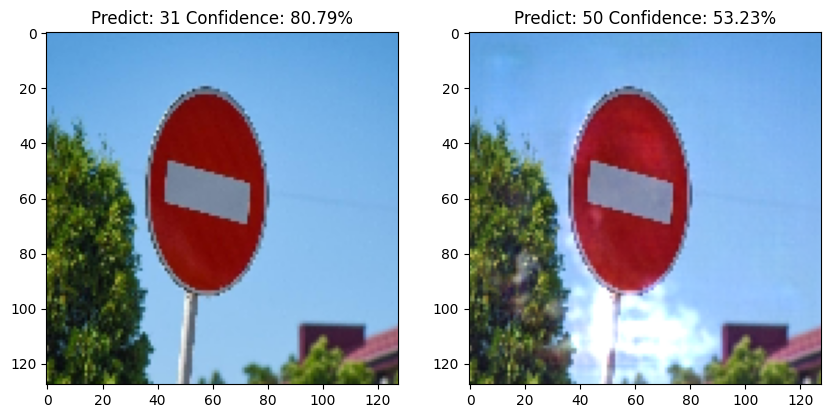

In [46]:
"""
3.5 Demo of ZOO optimize result 
"""
print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[ZOO_optimizer.predict], ZOO_optimizer.confidence.item()*100))
plt.imshow(ZOO_optimizer.attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))

50
Confidence: 53.22538614273071 %
best pos [39.96659315 54.9176428  29.28531251]
Largest Loss 6.723937034606934


True

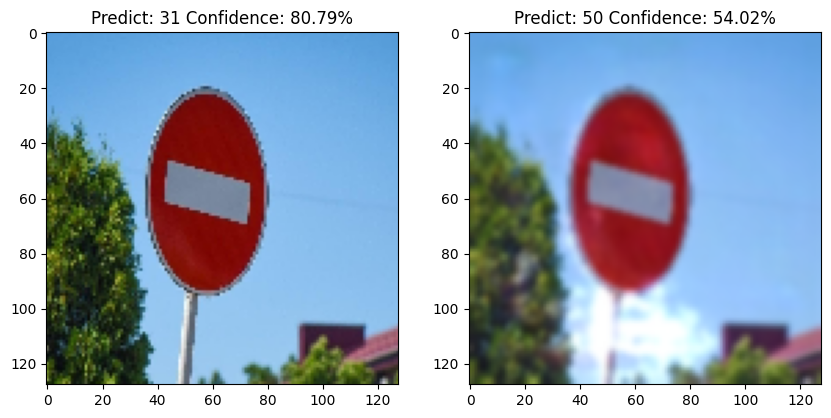

In [47]:
"""
3.5 Demo of ZOO optimize result + ГАУСС
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np

print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# Apply Gaussian blur to the attacked image
blurred_attack_img = cv2.GaussianBlur(ZOO_optimizer.attack_img, (5, 5), 0) # kernel size 5x5, sigma=0

# Re-evaluate with the blurred image
classifier.eval()
resize_img = cv2.resize(blurred_attack_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_blurred = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_blurred = torch.argmax(predict_blurred).item()
confidence_blurred = predict_blurred[index_blurred].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index_blurred], confidence_blurred*100))
plt.imshow(blurred_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/blurred_sim_light.png', (blurred_attack_img*255).clip(0,255).astype("uint8")[:,:,::-1])

50
Confidence: 53.22538614273071 %
best pos [39.96659315 54.9176428  29.28531251]
Largest Loss 6.723937034606934


True

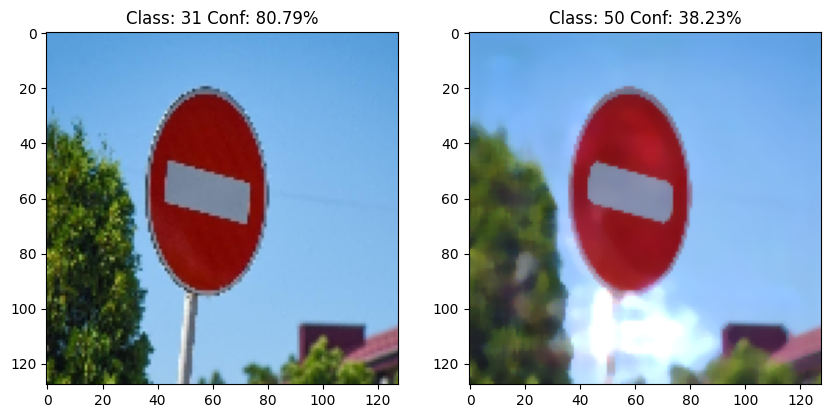

In [48]:
"""
3.5 Demo of ZOO optimize result + МЕДИАННЫЙ
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np

print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# Apply Median blur to the attacked image
blurred_attack_img = cv2.medianBlur(ZOO_optimizer.attack_img, 5) # kernel size 5

# Re-evaluate with the blurred image
classifier.eval()
resize_img = cv2.resize(blurred_attack_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_blurred = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_blurred = torch.argmax(predict_blurred).item()
confidence_blurred = predict_blurred[index_blurred].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_blurred], confidence_blurred*100))
plt.imshow(blurred_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/median_blurred_sim_light.png', (blurred_attack_img*255).clip(0,255).astype("uint8")[:,:,::-1])

Min/Max values after CLAHE: 10, 255
Min/Max normalized values: 0.0392156862745098, 1.0
Min/Max values after color transformation: 0, 255


True

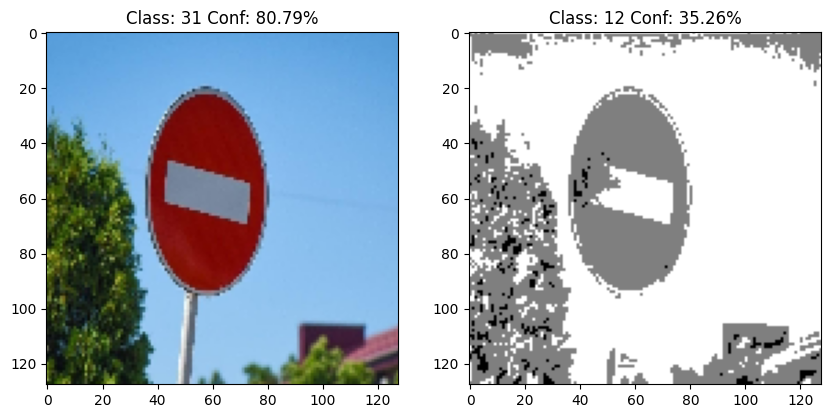

In [70]:
"""
3.5 Demo of ZOO optimize result + Контраст и цветовая палитра (исправлено)
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision

#print(LABELS[ZOO_optimizer.predict])
#print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
#print("best pos", ZOO_optimizer.global_best_pos)
#print("Largest Loss",ZOO_optimizer.global_best_value)

# 1. Convert to grayscale
gray_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2GRAY)

# 2. Enhance contrast (using CLAHE - Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))  # Adjust parameters as needed

# Scale to 0-255 and convert to uint8 for CLAHE
gray_attack_img_scaled = (gray_attack_img * 255).clip(0, 255).astype(np.uint8)

contrast_enhanced_img = clahe.apply(gray_attack_img_scaled)

# Check the range of values after CLAHE
print(f"Min/Max values after CLAHE: {np.min(contrast_enhanced_img)}, {np.max(contrast_enhanced_img)}")

# 3. Change the color palette
# Create a 3-channel image
color_transformed_img = np.zeros((contrast_enhanced_img.shape[0], contrast_enhanced_img.shape[1], 3), dtype=np.uint8)

# Normalize values to 0-1 range (instead of 0-100)
normalized_img = contrast_enhanced_img / 255.0

# Check the range of normalized values
print(f"Min/Max normalized values: {np.min(normalized_img)}, {np.max(normalized_img)}")

# Apply the color transformation rules
color_transformed_img[normalized_img <= 0.15] = [0, 0, 0]  # Black for brightness 0-10%
color_transformed_img[(normalized_img > 0.15) & (normalized_img <= 0.65)] = [127, 127, 127]  # Gray for brightness 10-50%
color_transformed_img[normalized_img > 0.65] = [255, 255, 255]  # White for brightness 50-100%

# Check the range of values after color transformation
print(f"Min/Max values after color transformation: {np.min(color_transformed_img)}, {np.max(color_transformed_img)}")

# 4. Re-evaluate with the transformed image
classifier.eval()
resize_img = cv2.resize(color_transformed_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_transformed = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_transformed = torch.argmax(predict_transformed)
confidence_transformed = predict_transformed[index_transformed].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_transformed], confidence_transformed*100))
plt.imshow(cv2.cvtColor(color_transformed_img, cv2.COLOR_BGR2RGB))  # Display as RGB

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/color_transformed_sim_light.png', color_transformed_img)

Min/Max V channel before CLAHE: 0.09656080603599548, 1.0
Min/Max V channel after CLAHE and before replacement: 11, 255
Min/Max V channel values after CLAHE (in HSV): 11.0, 255.0


True

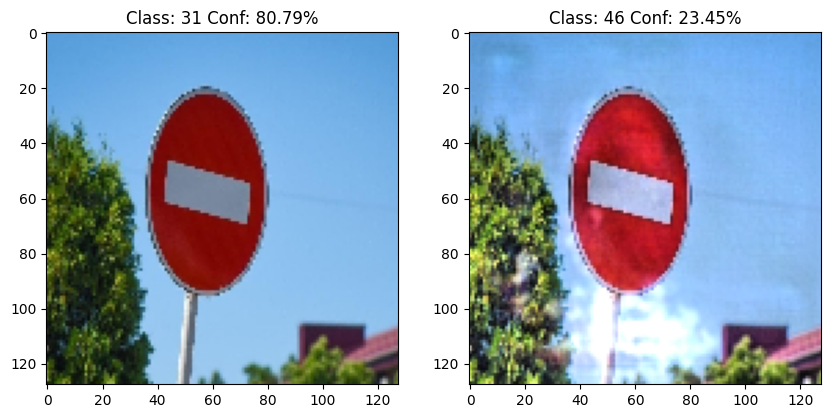

In [60]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision

# 1. Convert to HSV
hsv_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2HSV)

# 2. Enhance contrast (using CLAHE - Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))  # Adjust parameters as needed

# Apply CLAHE to the V channel only
v_channel = hsv_attack_img[:, :, 2]  # Extract the V channel
print(f"Min/Max V channel before CLAHE: {np.min(v_channel)}, {np.max(v_channel)}")

v_channel_scaled = (v_channel * 255).clip(0, 255).astype(np.uint8)  # Scale to 0-255
contrast_enhanced_v_channel = clahe.apply(v_channel_scaled)

# Normalize the V channel after CLAHE
v_channel_normalized = np.clip(contrast_enhanced_v_channel, 0, 255).astype(np.uint8)  # Clamp it.
print(f"Min/Max V channel after CLAHE and before replacement: {np.min(v_channel_normalized)}, {np.max(v_channel_normalized)}")


# Replace the V channel in the HSV image
hsv_attack_img[:, :, 2] = v_channel_normalized

# Check the range of values after CLAHE (V channel)
print(f"Min/Max V channel values after CLAHE (in HSV): {np.min(hsv_attack_img[:, :, 2])}, {np.max(hsv_attack_img[:, :, 2])}")


# 4. Re-evaluate with the transformed image - just use the enhanced HSV
color_transformed_img_bgr = cv2.cvtColor(hsv_attack_img, cv2.COLOR_HSV2BGR)  # Convert back to BGR for display

classifier.eval()
resize_img = cv2.resize(color_transformed_img_bgr, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_transformed = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_transformed = torch.argmax(predict_transformed)
confidence_transformed = predict_transformed[index_transformed].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_transformed], confidence_transformed*100))
plt.imshow(cv2.cvtColor(color_transformed_img_bgr, cv2.COLOR_BGR2RGB) / 255.0)  # Display as RGB

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/color_transformed_sim_light.png', color_transformed_img_bgr)

True

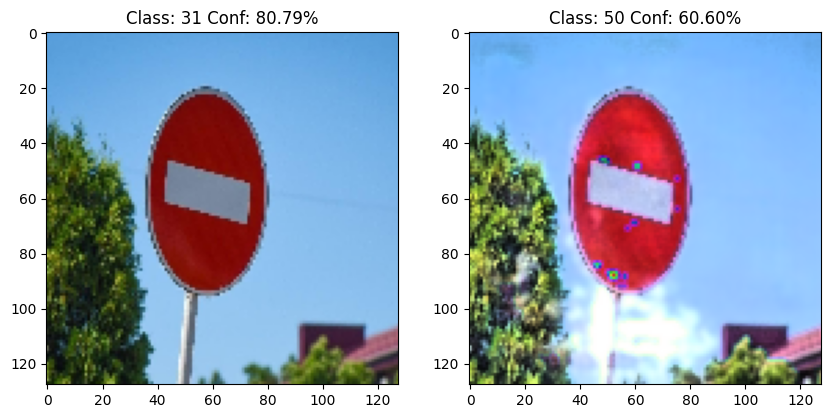

In [61]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision

# 1. Convert to HSV
hsv_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2HSV)

# 2. Enhance brightness and contrast (combined approach)

def enhance_brightness_contrast_hsv(hsv_img):
  """Улучшает яркость и контраст в HSV."""

  # 1. Размытие (Gaussian Blur) - для смягчения артефактов перед повышением яркости
  blur_kernel_size = (3, 3)  #  Размер ядра размытия.  Начните с небольшого значения
  hsv_img[:, :, 0] = cv2.GaussianBlur(hsv_img[:, :, 0], blur_kernel_size, 0)  # Размытие H
  hsv_img[:, :, 1] = cv2.GaussianBlur(hsv_img[:, :, 1], blur_kernel_size, 0)  # Размытие S
  #hsv_img[:, :, 2] = cv2.GaussianBlur(hsv_img[:, :, 2], blur_kernel_size, 0)  # Размытие V - blur is applied to original, not scaled


  # 2. Увеличение яркости (линейное масштабирование)
  brightness_factor = 1.1  # Подберите фактор (1 - без изменений, >1 - увеличение яркости, <1 - уменьшение)
  v_channel = hsv_img[:, :, 2].astype(np.float32)  # Convert to float for precise calculations
  v_channel = v_channel * brightness_factor  # Увеличиваем значения яркости
  v_channel = np.clip(v_channel, 0, 1) # Ensure clipping!
  #v_channel = np.clip(v_channel, 0, 255).astype(np.uint8) # Ensure clipping! -  Not now, since we use normalised
  # 3. Normalization
  v_channel = v_channel * 255 # scale to [0, 255] for CLAHE

  # 3. Увеличение контрастности (CLAHE)
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) # Подберите параметры CLAHE. ClipLimit уменьшен.
  v_channel_clahe = clahe.apply(np.uint8(v_channel)) # CLAHE needs uint8
  v_channel_clahe = np.clip(v_channel_clahe, 0, 255) # ensure it in range

  hsv_img[:, :, 2] = (v_channel_clahe/255.0)  # scale back to [0, 1]
  return hsv_img

hsv_attack_img = enhance_brightness_contrast_hsv(hsv_attack_img)

# 4. Re-evaluate with the transformed image - just use the processed HSV
color_transformed_img_bgr = cv2.cvtColor(hsv_attack_img, cv2.COLOR_HSV2BGR)  # Convert back to BGR for display

classifier.eval()
resize_img = cv2.resize(color_transformed_img_bgr, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_transformed = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_transformed = torch.argmax(predict_transformed)
confidence_transformed = predict_transformed[index_transformed].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_transformed], confidence_transformed*100))
plt.imshow(cv2.cvtColor(color_transformed_img_bgr, cv2.COLOR_BGR2RGB))  # Display as RGB

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/color_transformed_sim_light.png', color_transformed_img_bgr)

True

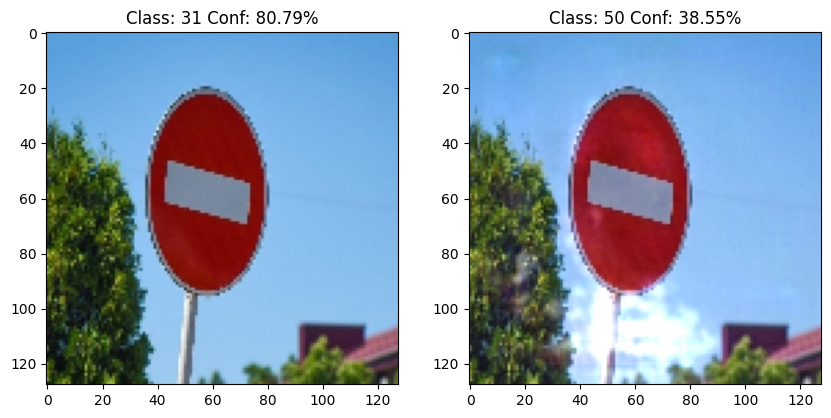

In [62]:
#просто вывод
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision

# 1. Convert to HSV
hsv_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2HSV)

# 4. Re-evaluate with the transformed image - just use the enhanced HSV
color_transformed_img_bgr = cv2.cvtColor(hsv_attack_img, cv2.COLOR_HSV2BGR)  # Convert back to BGR for display

# Масштабируем значения и преобразуем в uint8 перед отображением
if color_transformed_img_bgr.max() <= 1.0:  # Проверяем, что данные в диапазоне 0-1
    color_transformed_img_bgr = (color_transformed_img_bgr * 255).clip(0, 255).astype(np.uint8)

classifier.eval()
resize_img = cv2.resize(color_transformed_img_bgr, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_transformed = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_transformed = torch.argmax(predict_transformed)
confidence_transformed = predict_transformed[index_transformed].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_transformed], confidence_transformed*100))
plt.imshow(cv2.cvtColor(color_transformed_img_bgr, cv2.COLOR_BGR2RGB) / 255.0)  # Display as RGB

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/color_transformed_sim_light.png', color_transformed_img_bgr)

50
Confidence: 53.22538614273071 %
best pos [39.96659315 54.9176428  29.28531251]
Largest Loss 6.723937034606934


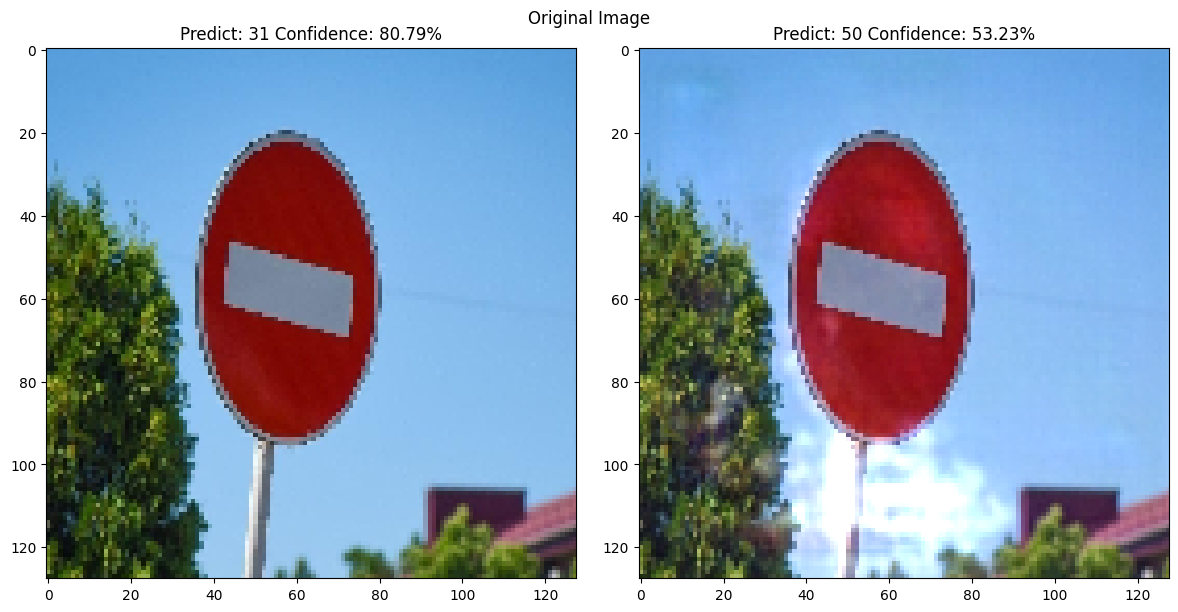

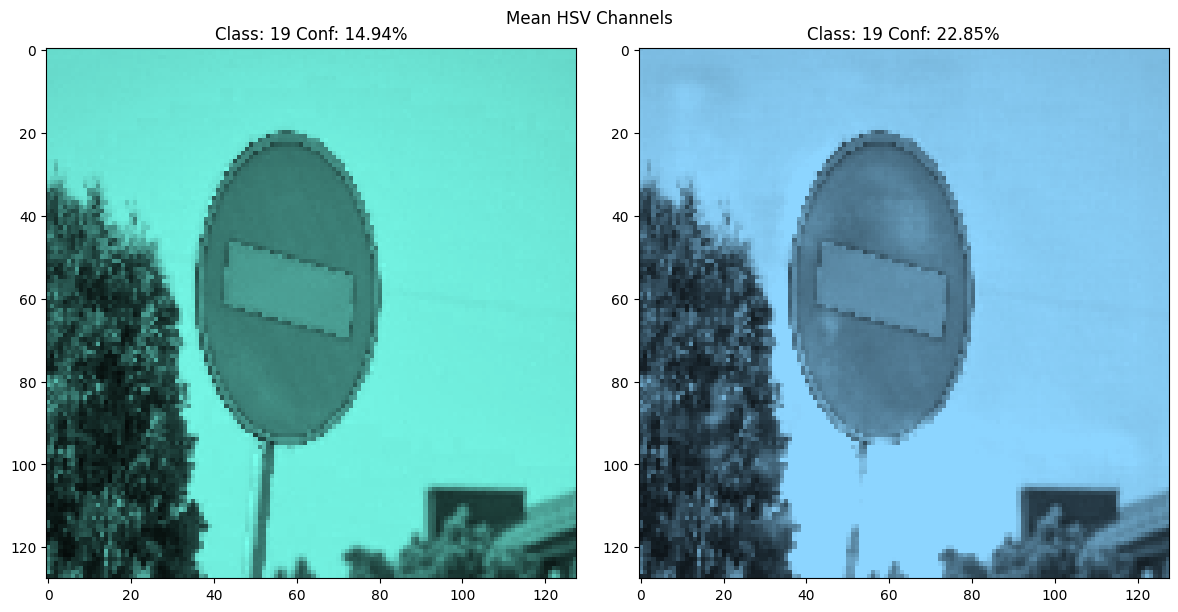

True

In [63]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision
from PIL import Image  # Import PIL


# --- Функции для расчета и применения усредненного HSV  ---
def apply_mean_hsv_channels(image_bgr):
    """
    Преобразует изображение в HSV, вычисляет среднее значение для каждого канала (H, S, V),
    заменяет все значения каналов на их средние значения и возвращает изображение в BGR.

    Args:
        image_bgr (numpy.ndarray): Исходное изображение в формате BGR.

    Returns:
        numpy.ndarray: Изображение BGR с усредненными каналами HSV.
    """
    hsv_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    # Вычисляем средние значения для каждого канала
    mean_h = np.mean(hsv_image[:, :, 0])
    mean_s = np.mean(hsv_image[:, :, 1])
    #mean_v = np.mean(hsv_image[:, :, 2])

    # Заменяем значения каналов на средние
    hsv_image[:, :, 0] = mean_h
    hsv_image[:, :, 1] = mean_s
    #hsv_image[:, :, 2] = mean_v

    return cv2.cvtColor(hsv_image, cv2.COLOR_HSV2BGR)


def predict_image(image, model, device, transform):
    """
    Предобрабатывает изображение и делает предсказание.

    Args:
        image (numpy.ndarray): Исходное изображение в формате BGR (OpenCV).
        model (torch.nn.Module):  Ваша модель.
        device (torch.device):  Устройство ('cpu' or 'cuda').
        transform (torchvision.transforms.Compose): Преобразования для предобработки.

    Returns:
        tuple: (predicted_class, confidence) or (None, None) in case of error
    """
    try:
        # Преобразование изображения в формат PIL
        img = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # cv2 использует BGR, а PIL и model - RGB

        # Предобработка изображения (применяем transform, который мы использовали раньше!)
        img_tensor = transform(img).to(device)
        img_tensor = img_tensor.unsqueeze(0)  # Добавляем размерность пакета (batch size)

        # Получаем предсказание
        with torch.no_grad():
            output = model(img_tensor)
            _, predicted_class = torch.max(output.data, 1)
            confidence = F.softmax(output, dim=1)  # Use softmax to get probabilities
            confidence_score = confidence.max().item()

        return predicted_class.item(), confidence_score

    except Exception as e:
        print(f"Error predicting image: {e}")
        return None, None

# --- Основной код ---

# --- 3.5 Demo of ZOO optimize result ---
print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# 1. Convert to HSV
hsv_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2HSV)

# 4. Re-evaluate with the transformed image - just use the enhanced HSV
color_transformed_img_bgr = cv2.cvtColor(hsv_attack_img, cv2.COLOR_HSV2BGR)  # Convert back to BGR for display

# Масштабируем значения и преобразуем в uint8 перед отображением
if color_transformed_img_bgr.max() <= 1.0:  # Проверяем, что данные в диапазоне 0-1
    color_transformed_img_bgr = (color_transformed_img_bgr * 255).clip(0, 255).astype(np.uint8)


# --- Applying Mean HSV Channels ---
# Для оригинального изображения (test_img больше не используется, используем test_img для сравнения)
test_img_mean_hsv = apply_mean_hsv_channels(test_img)  # test_img - оригинальное изображение (BGR)

# Для атакованного изображения
color_transformed_img_bgr_mean_hsv = apply_mean_hsv_channels(color_transformed_img_bgr)

# --- Prediction with Mean HSV Channels ---
# Original Image
classifier.eval()
resize_img = cv2.resize(test_img_mean_hsv, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)
predict_original_mean_hsv = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)
index_original_mean_hsv = torch.argmax(predict_original_mean_hsv)
confidence_original_mean_hsv = predict_original_mean_hsv[index_original_mean_hsv].item()

# Attacked Image
resize_img = cv2.resize(color_transformed_img_bgr_mean_hsv, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)
predict_transformed_mean_hsv = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)
index_transformed_mean_hsv = torch.argmax(predict_transformed_mean_hsv)
confidence_transformed_mean_hsv = predict_transformed_mean_hsv[index_transformed_mean_hsv].item()



# --- Display Results - Plot 1: Original Image ---
plt.figure(figsize=(12, 6))
plt.suptitle("Original Image")

# Original Image
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

# Attacked Image (Original Transformation)
plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[ZOO_optimizer.predict], ZOO_optimizer.confidence.item()*100))
plt.imshow(ZOO_optimizer.attack_img[:,:,::-1])


plt.tight_layout()
plt.show()

# --- Display Results - Plot 2: Mean HSV Channels ---
plt.figure(figsize=(12, 6))
plt.suptitle("Mean HSV Channels")

# Original Image with Mean HSV
plt.subplot(121)
plt.title("Original Image (Mean HSV)")
plt.imshow(cv2.cvtColor(test_img_mean_hsv, cv2.COLOR_BGR2RGB))
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_original_mean_hsv], confidence_original_mean_hsv*100))

# Attacked Image with Mean HSV
plt.subplot(122)
plt.title("Attacked Image (Mean HSV)")
plt.imshow(cv2.cvtColor(color_transformed_img_bgr_mean_hsv, cv2.COLOR_BGR2RGB) / 255.0)  # Display as RGB
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_transformed_mean_hsv], confidence_transformed_mean_hsv*100))

plt.tight_layout()
plt.show()


# Save Images
cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/color_transformed_sim_light.png', color_transformed_img_bgr)
cv2.imwrite('workspace/test_img_mean_hsv.png', test_img_mean_hsv)
cv2.imwrite('workspace/color_transformed_img_bgr_mean_hsv.png', color_transformed_img_bgr_mean_hsv)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-127979.305..254.92941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-507.03784..0.9995575].


50
Confidence: 53.22538614273071 %
best pos [39.96659315 54.9176428  29.28531251]
Largest Loss 6.723937034606934


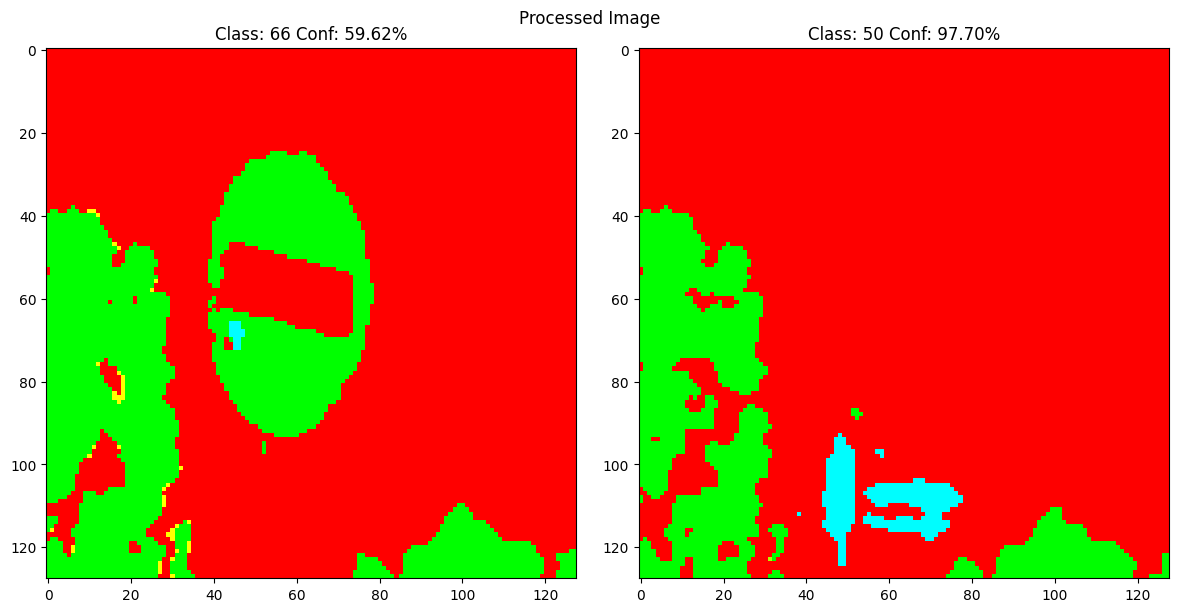

True

In [64]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision
from PIL import Image  # Import PIL


def process_hsv(image_bgr, method="invert_median", ksize=3, clipLimit=2.0, tileGridSize=(8, 8)):
    """
    Обрабатывает изображение в HSV с использованием различных методов.

    Args:
        image_bgr (numpy.ndarray): Исходное изображение в формате BGR.
        method (str): Метод обработки: "invert", "median", "clahe", "invert_median".
        ksize (int): Размер ядра для медианной фильтрации.
        clipLimit (float): Параметр clipLimit для CLAHE.
        tileGridSize (tuple): Параметр tileGridSize для CLAHE.

    Returns:
        numpy.ndarray: Обработанное изображение BGR.
    """
    hsv_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv_image)

    if method == "invert":
        h = 180 - h  # Диапазон H: 0-180
        s = 255 - s
        v = 255 - v
    elif method == "median":
        h = cv2.medianBlur(h, ksize=ksize)
        s = cv2.medianBlur(s, ksize=ksize)
        v = cv2.medianBlur(v, ksize=ksize)
    elif method == "clahe":
        clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
        v = clahe.apply(v)
    elif method == "invert_median":
        h = 180 - h
        s = 255 - s
        v = 255 - v
        h = cv2.medianBlur(h, ksize=ksize)
        s = cv2.medianBlur(s, ksize=ksize)
        v = cv2.medianBlur(v, ksize=ksize)
    # Добавьте else if method == "median_clahe":  ... и т.д. для других комбинаций

    hsv_image = cv2.merge((h, s, v))
    return cv2.cvtColor(hsv_image, cv2.COLOR_HSV2BGR)


def predict_image(image, model, device, transform):
    """
    Предобрабатывает изображение и делает предсказание.

    Args:
        image (numpy.ndarray): Исходное изображение в формате BGR (OpenCV).
        model (torch.nn.Module):  Ваша модель.
        device (torch.device):  Устройство ('cpu' or 'cuda').
        transform (torchvision.transforms.Compose): Преобразования для предобработки.

    Returns:
        tuple: (predicted_class, confidence) or (None, None) in case of error
    """
    try:
        # Преобразование изображения в формат PIL
        img = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # cv2 использует BGR, а PIL и model - RGB

        # Предобработка изображения (применяем transform, который мы использовали раньше!)
        img_tensor = transform(img).to(device)
        img_tensor = img_tensor.unsqueeze(0)  # Добавляем размерность пакета (batch size)

        # Получаем предсказание
        with torch.no_grad():
            output = model(img_tensor)
            _, predicted_class = torch.max(output.data, 1)
            confidence = F.softmax(output, dim=1)  # Use softmax to get probabilities
            confidence_score = confidence.max().item()

        return predicted_class.item(), confidence_score

    except Exception as e:
        print(f"Error predicting image: {e}")
        return None, None


# --- Основной код ---

# --- 3.5 Demo of ZOO optimize result ---
print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)


#  Применяем обработку к изображениям
processed_test_img = process_hsv(test_img, method="invert_median", ksize=3)  # или другой метод
processed_attack_img = process_hsv(ZOO_optimizer.attack_img, method="invert_median", ksize=3)

# --- Prediction ---
# Original Image with Processed HSV
classifier.eval()
resize_img = cv2.resize(processed_test_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)
predict_original_processed = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)
index_original_processed = torch.argmax(predict_original_processed)
confidence_original_processed = predict_original_processed[index_original_processed].item()

# Attacked Image with Processed HSV
resize_img = cv2.resize(processed_attack_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)
predict_transformed_processed = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)
index_transformed_processed = torch.argmax(predict_transformed_processed)
confidence_transformed_processed = predict_transformed_processed[index_transformed_processed].item()


# --- Display Results ---
plt.figure(figsize=(12, 6))
plt.suptitle("Processed Image")

# Original Image
plt.subplot(121)
plt.title("Original Image (Processed)")
plt.imshow(cv2.cvtColor(processed_test_img, cv2.COLOR_BGR2RGB))
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_original_processed], confidence_original_processed*100))

# Attacked Image
plt.subplot(122)
plt.title("Attacked Image (Processed)")
plt.imshow(cv2.cvtColor(processed_attack_img, cv2.COLOR_BGR2RGB) / 255.0)  # Display as RGB
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_transformed_processed], confidence_transformed_processed*100))


plt.tight_layout()
plt.show()


# Save Images
cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/test_img_processed.png', processed_test_img)
cv2.imwrite('workspace/attack_img_processed.png', processed_attack_img)

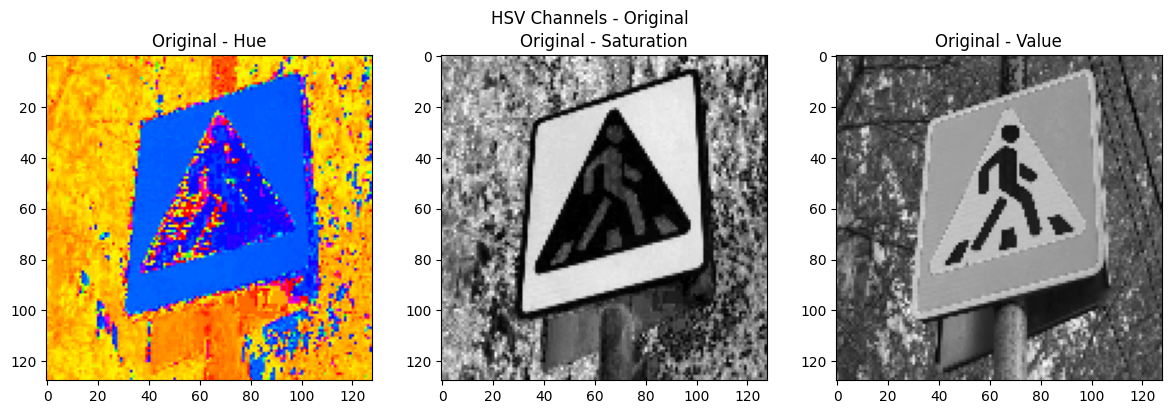

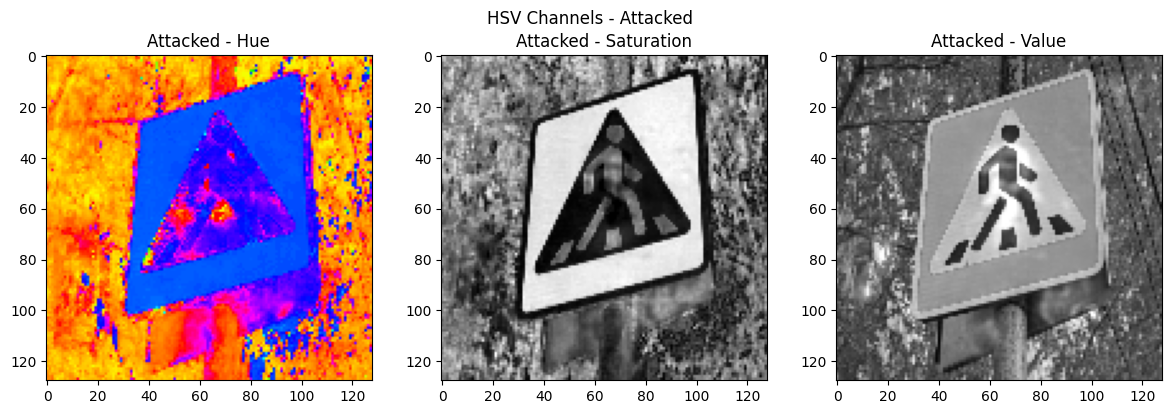

In [30]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_hsv_layers(image, title):
    """
    Отображает каналы HSV для заданного изображения.

    Args:
        image: Изображение в формате BGR (OpenCV).
        title: Заголовок для отображения.
    """
    hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv_img)

    plt.figure(figsize=(12, 4))  # Создаем новую фигуру для каждого изображения

    plt.subplot(131)
    plt.imshow(h, cmap='hsv')  # Hue
    plt.title(f"{title} - Hue")

    plt.subplot(132)
    plt.imshow(s, cmap='gray')  # Saturation
    plt.title(f"{title} - Saturation")

    plt.subplot(133)
    plt.imshow(v, cmap='gray')  # Value
    plt.title(f"{title} - Value")

    plt.suptitle(f"HSV Channels - {title}")
    plt.tight_layout()
    plt.show()


def display_hsv_layers_for_attack(original_image_path, attack_image):
    """
    Отображает каналы HSV для исходного и атакованного изображений.

    Args:
        original_image_path: Путь к исходному изображению.
        attack_image: Атакованное изображение (в формате BGR или [0,1]).
    """
    # Загрузка исходного изображения
    original_img = original_image_path

    if original_img is None:
        print(f"Не удалось загрузить исходное изображение по пути: {original_image_path}")
        return

    # Отображение каналов HSV для оригинального изображения
    display_hsv_layers(original_img, "Original")

    # Преобразование атакованного изображения в формат BGR, если это необходимо.
    if attack_image is not None: #check for none
        if attack_image.max() <= 1.0:  # If it is normalized
          attack_img = (attack_image * 255).clip(0, 255).astype(np.uint8) # scale it
        else:
          attack_img = attack_image.astype(np.uint8) # assuming its in BGR
        display_hsv_layers(attack_img, "Attacked")
    else:
        print("No attack image provided.")


# Пример использования
image_path = test_img  # Путь к вашему исходному изображению
# Замените ZOO_optimizer.attack_img на ваше атакованное изображение
# Убедитесь, что attack_image либо путь к изображению, либо ndarray в BGR формате или [0,1]
# Для примера, создадим фейковое атакованное изображение
attack_image = ZOO_optimizer.attack_img # this is a placeholder, replace with your attack_image
display_hsv_layers_for_attack(image_path, attack_image)

Original Image:


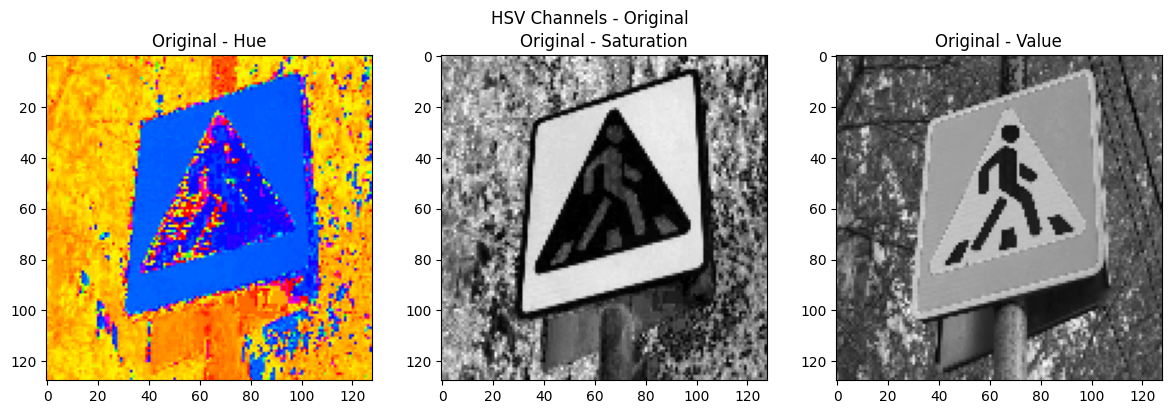

Predictions for Original HSV Channels:
  Channel H: Predicted Class = 9, Confidence = 0.8299
  Channel S: Predicted Class = 50, Confidence = 0.6178
  Channel V: Predicted Class = 50, Confidence = 0.6178

Attacked Image:


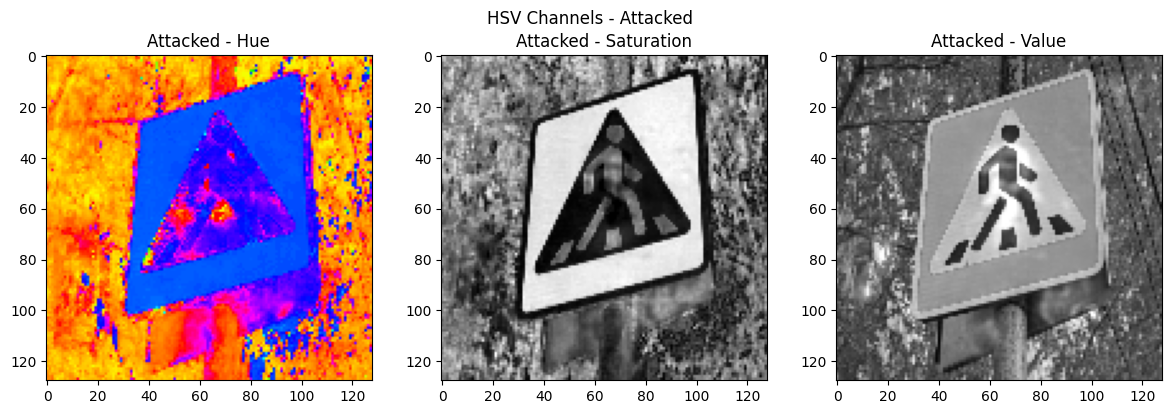

Predictions for Attacked HSV Channels:
  Channel H: Predicted Class = 7, Confidence = 0.1980
  Channel S: Predicted Class = 98, Confidence = 0.6786
  Channel V: Predicted Class = 9, Confidence = 0.8033


In [43]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision.transforms as transforms
from PIL import Image
import torch.nn.functional as F


# 1. Функция для предобработки изображения и получения предсказаний
def predict_hsv_channels(image, model, device, transform, original_image_path=""):

    try:
        # Преобразование в HSV
        hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv_img)

        # Получаем предсказания для каждого канала
        predictions = []
        for channel, channel_name in zip([h, s, v], ["H", "S", "V"]):
            # Преобразование канала в формат PIL (как исходное изображение)
            # Так как каналы - это Grayscale images
            channel_img = Image.fromarray(channel) # Преобразуем в PIL image

            # Преобразование изображения в тензор PyTorch и добавление канала
            # Изменяем здесь:
            transform_with_channel = transforms.Compose([
                transforms.Resize(CLASSIFIER_INPUT_SHAPE),
                transforms.Grayscale(num_output_channels=3), # Преобразование в 3-канальное Grayscale
                transforms.ToTensor(),
                # Если использовалась нормализация:
                #transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Ваша нормализация
            ])
            img_tensor = transform_with_channel(channel_img).to(device)
            img_tensor = img_tensor.unsqueeze(0)  # Добавляем размерность пакета (batch size)

            # Получаем предсказание
            with torch.no_grad():
                output = model(img_tensor)
                _, predicted_class = torch.max(output.data, 1)
                confidence = F.softmax(output, dim=1)
                confidence_score = confidence.max().item()

            predictions.append((predicted_class.item(), confidence_score))
            #print(f"Channel {channel_name} Predicted Class: {predicted_class.item()}, Confidence: {confidence_score:.4f}") #debug

        return predictions

    except Exception as e:
        print(f"Error predicting HSV channels: {e}")
        print(f"Path to original image: {original_image_path}")  # Для отладки
        return None


# 2. Функция для отображения и анализа HSV каналов (модифицированная)
def display_hsv_layers_for_attack_and_predict(original_image, attack_image, model, device, transform, original_image_path=""):

    # 1. Обработка исходного изображения
    print("Original Image:")
    display_hsv_layers(original_image, "Original")
    original_predictions = predict_hsv_channels(original_image, model, device, transform, original_image_path=original_image_path)
    if original_predictions:
      print("Predictions for Original HSV Channels:")
      for i, (pred_class, confidence) in enumerate(original_predictions):
          print(f"  Channel {['H', 'S', 'V'][i]}: Predicted Class = {pred_class}, Confidence = {confidence:.4f}")

    # 2. Обработка атакованного изображения
    if attack_image is not None:
        print("\nAttacked Image:")
        if attack_image.max() <= 1.0:  # Если это нормализованное изображение
            attack_img = (attack_image * 255).clip(0, 255).astype(np.uint8)  # scale it
        else:
            attack_img = attack_image.astype(np.uint8) # assuming its in BGR
        display_hsv_layers(attack_img, "Attacked")
        attack_predictions = predict_hsv_channels(attack_img, model, device, transform, original_image_path=original_image_path)  # передаем путь для отладки
        if attack_predictions:
            print("Predictions for Attacked HSV Channels:")
            for i, (pred_class, confidence) in enumerate(attack_predictions):
                print(f"  Channel {['H', 'S', 'V'][i]}: Predicted Class = {pred_class}, Confidence = {confidence:.4f}")
    else:
        print("No attack image provided.")


image_path = "workspace_physical/saratov.jpg" # Путь к вашему изображению
display_hsv_layers_for_attack_and_predict(test_img, ZOO_optimizer.attack_img, classifier, device, transform, image_path)